In [1]:
# Import libraries
import numpy as np
import tensorflow as tf
import keras  # Keras is the high-level API of TensorFlow
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Convert CIFAR datasets to Torch TensorDataset
def to_tensor_dataset(ds):
    imgs = torch.tensor(np.stack(ds["img"])).float() / 255.0
    labels = torch.tensor(ds["label"]).long()
    reshaped_imgs = imgs.reshape(imgs.shape[0], 3, 32, 32)
    return TensorDataset(reshaped_imgs, labels)


train_dataset = to_tensor_dataset(train_cifar)
val_dataset = to_tensor_dataset(val_cifar)
test_dataset = to_tensor_dataset(test_cifar)

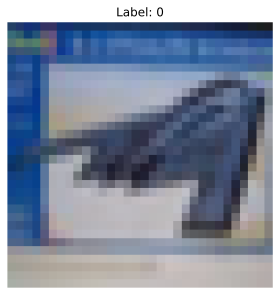

In [ ]:
# PLEASE DO NOT CHANGE THIS CODE

# Load the cifar10 dataset and split train/test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Split train/valid from the training set
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=5)

print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Validation shape: X_val = " + str(X_val.shape) + ", y_val = " + str(y_val.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

In [ ]:
# Show some samples in the dataset
import matplotlib.pyplot as plt

imgplot = plt.imshow(X_train[5])
plt.show()
imgplot = plt.imshow(X_test[10])
plt.show()

train_data: torch.float32
train_labels: torch.int64
val_data: torch.float32
val_labels: torch.int64
test_data: torch.float32
test_labels: torch.int64
Training data range 0.0 - 1.0
Val data range 0.0 - 1.0
Test data range 0.0 - 1.0


In [ ]:
# Your code goes here
# Normalize pixel values
X_train, X_test = X_train / 255.0, X_test / 255.0

In [ ]:
# Import library
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization

# Initialize AlexNet as an Sequential model.
# A Sequential model is appropriate for a plain stack of layers where each layer has exactly one input tensor and one output tensor.
AlexNet = Sequential(name='AlexNet')

# Block 1
AlexNet.add(
    Conv2D(filters=96, input_shape=(32, 32, 3), kernel_size=(11, 11), strides=(4, 4), padding='same', name='Block_1_Conv')
)  # padding="same" means input and output have the same spatial dimension.
AlexNet.add(Activation('relu'))  # Add RELU activation function
AlexNet.add(
    MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same', name='Block_1_MaxPool')
)  # Overlapping MaxPooling since the pooling kernel (3x3) is larger than the pooing stride (2x2).

# Block 2
AlexNet.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), padding='same', name='Block_2_Conv'))
AlexNet.add(Activation('relu'))  # Shorter way wot write: AlexNet.add(Conv2D(..., activation='relu'))
AlexNet.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same', name='Block_2_maxPool'))

# Block 3
AlexNet.add(Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), padding='same', name='Block_3_Conv'))
AlexNet.add(Activation('relu'))

# Block 4
AlexNet.add(Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), padding='same', name='Block_4_Conv'))
AlexNet.add(Activation('relu'))

# Block 5
AlexNet.add(Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), padding='same', name='Block_5_Conv'))
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same', name='Block_5_MaxPool'))

# Flatten
AlexNet.add(Flatten())  # Reshape the tensor to 1D tensor so that it can be used as input of a fully connected (fc) layer

# Fully connected (FC) layer 1
AlexNet.add(Dense(4096))
AlexNet.add(Activation('relu'))  # Shorter way wot write: AlexNet.add(Dense(4096, activation='relu'))
AlexNet.add(Dropout(rate=0.4))  # Dropout with drop rate. This is to force the layer to learn general features.

# Fully connected (FC) layer 2
AlexNet.add(Dense(4096))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(Dropout(rate=0.4))

# Fully connected (FC) layer 3
AlexNet.add(Dense(1000))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(Dropout(rate=0.4))

# Fully connected (FC) layer 3
AlexNet.add(Dense(10))  # Number of output classes
AlexNet.add(Activation('softmax'))  # Classification network often ends with softmax activation function.

# Model Summary
AlexNet.summary()

# Example of non-trainable parameters: statistics in BatchNormalization layers. They're updated with mean and variance, but they're not "trained with backpropagation".

In [ ]:
# Compile the model
AlexNet.compile(
    loss=tf.keras.losses.sparse_categorical_crossentropy,  # Define loss function
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    metrics=['accuracy'],
)  # Define initial learning rate and metrics.

torch.Size([32, 3, 32, 32])
torch.Size([32])
Before flattening: torch.Size([32, 64, 8, 8])
Vectorize: torch.Size([32, 4096])
fc1: torch.Size([32, 512])
Output: torch.Size([32, 10])
 
torch.Size([32, 10])
torch.Size([32])
 
Loss:
tensor(2.2929, grad_fn=<NllLossBackward0>)


In [ ]:
### Create a callback ModelCheckpoint: this callback will save a better version of model every time the optimizer finds one.
#### filepath: path to save the better model.
#### monitor: metrics to identify how a model is considered to be better.
#### mode='auto'/'max'/'min': to tell if the larger/smaller the metric, the better the model.
#### verbose: output log.
#### save_best_only: only save the best model instead off all better models along the training.

# Create a callback ModelCheckpoint. This callback will save the model when finding one better than the current best.
mc = keras.callbacks.ModelCheckpoint(
    # filepath="epoch-{epoch:02d}.hdf5",  # Path to save the model
    filepath="epoch-{epoch:02d}.keras",  # Path to save the model
    monitor='val_loss',  # Metric to evaluate the model performance when looking for a better model.
    mode='min',  # mode='auto'/'max'/'min': the monitor should be max/min to be better.
    # In auto mode, the mode is set to max if the quantities monitored are 'acc' or start with 'fmeasure' (f-score) and are set to min for the rest of the quantities.
    verbose=0,  # Inform every time a better model is found and saved.
    save_best_only=True,
)  # Only save the model if the current training epoch is the best. 'False' means save models of all training epochs

# Train the model. Using Colab for training
history = AlexNet.fit(
    X_train,
    y_train,  # Data feature and data label
    batch_size=512,  # Batch size
    epochs=30,  # Number of training epochs
    validation_data=(X_val, y_val),  # Validation set
    callbacks=[mc],
)  # Use callback ModelCheckpoint during the training

Before flattening: torch.Size([2, 64, 8, 8])
Vectorize: torch.Size([2, 4096])
fc1: torch.Size([2, 512])
Output: torch.Size([2, 10])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
            Conv2d-3           [-1, 64, 16, 16]          18,496
       BatchNorm2d-4           [-1, 64, 16, 16]             128
            Linear-5                  [-1, 512]       2,097,664
            Linear-6                   [-1, 10]           5,130
Total params: 2,122,378
Trainable params: 2,122,378
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.75
Params size (MB): 8.10
Estimated Total Size (MB): 8.86
----------------------------------------------------------------


In [ ]:
# Visualize training and validation performance
f, ax = plt.subplots(2, 1)

# Plot training and validation loss
ax[0].plot(history.history['loss'], color='b', label='Training Loss')
ax[0].plot(history.history['val_loss'], color='r', label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history.history['accuracy'], color='b', label='Training Accuracy')
ax[1].plot(history.history['val_accuracy'], color='r', label='Validation Accuracy')

plt.legend()

In [ ]:
train_accuracies, val_accuracies, losses, net = train_cifar_10(num_epochs=15, learning_rate=0.001)

Training:   7%|▋         | 1/15 [00:35<08:12, 35.21s/it]

Epoch 1/15, Train Loss: 1.7426, Val Loss: 1.5409


Training:  13%|█▎        | 2/15 [01:13<08:03, 37.17s/it]

Epoch 2/15, Train Loss: 1.5044, Val Loss: 1.5639


Training:  20%|██        | 3/15 [01:55<07:49, 39.13s/it]

...

Epoch 13/15, Train Loss: 0.5654, Val Loss: 1.6374


Training:  93%|█████████▎| 14/15 [08:59<00:38, 38.98s/it]

Epoch 14/15, Train Loss: 0.5082, Val Loss: 1.7924


Training: 100%|██████████| 15/15 [09:39<00:00, 38.61s/it]

Epoch 15/15, Train Loss: 0.4465, Val Loss: 1.8288


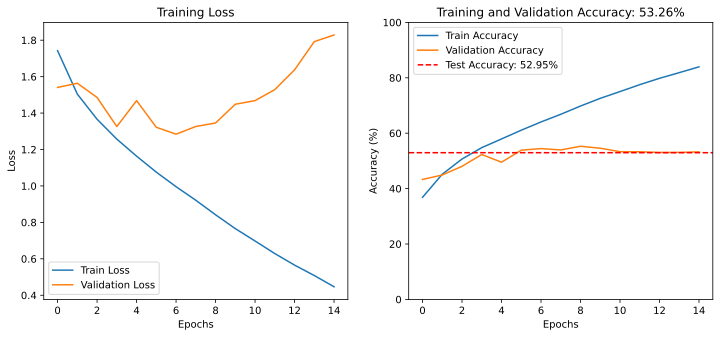

In [ ]:
# Let us load a saved model and evaluate its performance on the test set

import glob
import os

# Find the best model based on validation loss (lowest validation loss is best)
list_of_files = glob.glob('/content/*.keras')
latest_file = max(list_of_files, key=os.path.getctime)  # Assuming the latest file is the best based on ModelCheckpoint saving the best only

model = tf.keras.models.load_model(latest_file)
result = AlexNet.evaluate(X_test, y_test)  # If unspecified, batch_size will default to 32

In [ ]:
# Show the model performance
print(AlexNet.metrics_names)  # result[0] is loss, result[1] is accuracy. The metrics are defined in AlexNet.complie(...)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0], result[1]))

In [ ]:
# This is to delete all saved models (*.hdf5) in the current directory

'''import os
import glob
# Get a list of all the file paths that ends with .txt from in specified directory
fileList = glob.glob('*.hdf5')
# Iterate over the list of filepaths & remove each file.
for filePath in fileList:
  try:
    os.remove(filePath)
  except:
    print("Error while deleting file : ", filePath)'''